# Fair PCA — Comparação Experimental

Notebook para comparar experimentalmente **seis** algoritmos de redução de dimensionalidade justa (*Fair PCA*):

1. **PCA clássico**
2. **Fair PCA clássico** (combinação linear fixa entre covariância global e diferença de covariâncias dos grupos)
3. **U-FPCA** (Unconstrained Fair PCA — Pelegrina & Duarte), busca de α que minimiza o quadrado da disparidade
4. **C-FPCA** (Constrained Fair PCA — Pelegrina & Duarte), idem, sujeito a `R_A(U) ≤ τ` e `R_B(U) ≤ τ`
5. **Barganha U-FPCA** (proposto): solução de Nash ponderada sobre utilidades `u_g = 1/R_g(U)`, otimizada na variedade de Stiefel
6. **Barganha C-FPCA** (proposto): solução de Nash ponderada sobre utilidades `u_g = -R_g(U)`, com ponto de desacordo `d_g = -τ`, otimizada na variedade de Stiefel

O notebook é modular: basta trocar as configurações da **Seção 3** para rodar com outro dataset/coluna sensível.

> **Nota de implementação:** `pymanopt`/`cvxpy` não são pré-requisitos — a otimização Riemanniana (gradiente + retração QR + Armijo) e a busca em α (seção áurea) são implementadas apenas com NumPy/SciPy, o que torna o notebook autocontido.


## 1. Instalação das bibliotecas

In [343]:
# Todas as dependências usadas neste notebook são bibliotecas científicas padrão.
# Descomente a linha abaixo caso alguma não esteja instalada no seu ambiente.

# %pip install numpy scipy pandas matplotlib scikit-learn


## 2. Imports

In [344]:
import time
import warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)

RNG = np.random.default_rng(42)


## 2.1 Diagnóstico do CSV

Antes de fixar `COLUMN_NAMES` / `GROUP_COLUMN` no `CONFIG`, inspecionamos o
CSV cru de lsac pois não havia cabeçalho contendo os nomes das colunas no dataset original. Desta forma podemos tentar indentificar a coluna sensível.


In [ ]:
CAMINHO_CSV   = "lsac.csv"   
TEM_CABECALHO = False       

_df_raw = pd.read_csv(CAMINHO_CSV, header=0 if TEM_CABECALHO else None)
if not TEM_CABECALHO:
    _df_raw.columns = [f"col{i}" for i in range(_df_raw.shape[1])]

print(f"{_df_raw.shape[0]} linhas, {_df_raw.shape[1]} colunas\n")
diag_rows = []
for c in _df_raw.columns:
    serie = _df_raw[c]
    nun = serie.nunique(dropna=True)
    diag_rows.append(dict(
        coluna=c,
        n_valores_unicos=nun,
        exemplo_valores=sorted(serie.dropna().unique())[:6],
        min=serie.min() if pd.api.types.is_numeric_dtype(serie) else None,
        max=serie.max() if pd.api.types.is_numeric_dtype(serie) else None,
    ))
diag_df = pd.DataFrame(diag_rows)
print("Colunas com poucos valores distintos são as candidatas a atributo sensível")
print("(ex.: sexo, raça, escolaridade costumam ter 2 a 5 valores únicos):\n")
display(diag_df.sort_values("n_valores_unicos"))


26551 linhas, 12 colunas

Colunas com poucos valores distintos são as candidatas a atributo sensível
(ex.: sexo, raça, escolaridade costumam ter 2 a 5 valores únicos):



,coluna,n_valores_unicos,exemplo_valores,min,max
3,col3,2,"[1, 2]",1.000000,2.000000
4,col4,2,"[1, 2]",1.000000,2.000000
11,col11,2,"[0, 1]",0.000000,1.000000
5,col5,3,"[1, 2, 3]",1.000000,3.000000
7,col7,5,"[1, 2, 3, 4, 5]",1.000000,5.000000
6,col6,6,"[1, 2, 3, 4, 5, 6]",1.000000,6.000000
9,col9,26,"[1.5, 1.6, 1.7, 1.8, 1.9, 2.0]",1.500000,4.000000
2,col2,55,"[0, 10, 12, 14, 15, 16]",0.000000,72.000000
8,col8,118,"[11.0, 12.0, 13.5, 14.0, 14.5, 15.0]",11.000000,48.000000
1,col1,598,"[-6.44, -3.46, -3.27, -3.21, -3.19, -3.16]",-6.440000,4.010000


### 2.2 Identificando a coluna de raça pela proporção conhecida (LSAC)

O artigo de referência reporta a divisão exata do atributo sensível nessa base: **1790 amostras
"black" vs. 24761 "white + other"** (~6,7% vs. ~93,3%). Em vez de adivinhar pelo
nome/posição, comparamos essa proporção com a de cada coluna categórica candidata
— a que mais se aproxima de 6,7%/93,3% é a coluna de raça.


In [346]:
PROPORCAO_MINORIA_PAPER = 1790 / (1790 + 24761)  # ~0.0674

candidatas = [c for c in _df_raw.columns if _df_raw[c].nunique(dropna=True) <= 6]

print(f"Proporção esperada da categoria minoritária (paper): {PROPORCAO_MINORIA_PAPER:.4f}\n")
print("Distribuição de cada coluna candidata (categórica, poucos valores únicos):\n")

melhor_col, melhor_dist = None, np.inf
for c in candidatas:
    vc = _df_raw[c].value_counts(normalize=True).sort_values()
    prop_minoria = vc.iloc[0]
    dist = abs(prop_minoria - PROPORCAO_MINORIA_PAPER)
    marca = "  <-- candidata a 'race'" if dist < 0.03 else ""
    print(f"{c}: {dict(vc.round(4))}{marca}")
    if dist < melhor_dist:
        melhor_col, melhor_dist = c, dist

print(f"\nColuna mais compatível com a proporção de raça do paper: '{melhor_col}' "
      f"(diferença de {melhor_dist:.4f})")


Proporção esperada da categoria minoritária (paper): 0.0674

Distribuição de cada coluna candidata (categórica, poucos valores únicos):

col3: {1: np.float64(0.0895), 2: np.float64(0.9105)}  <-- candidata a 'race'
col4: {2: np.float64(0.4398), 1: np.float64(0.5602)}
col5: {2: np.float64(0.0674), 3: np.float64(0.1064), 1: np.float64(0.8262)}  <-- candidata a 'race'
col6: {1: np.float64(0.0277), 2: np.float64(0.0816), 6: np.float64(0.0876), 5: np.float64(0.1714), 4: np.float64(0.2767), 3: np.float64(0.3549)}
col7: {1: np.float64(0.0245), 5: np.float64(0.079), 2: np.float64(0.1062), 3: np.float64(0.3648), 4: np.float64(0.4254)}
col11: {0: np.float64(0.199), 1: np.float64(0.801)}

Coluna mais compatível com a proporção de raça do paper: 'col5' (diferença de 0.0000)


## 3. Configurações gerais

Os dois datasets do trabalho (`lsac` e `tcred`) são configurados aqui e **rodados
separadamente** nas seções seguintes — cada um gera seus próprios resultados,
gráficos e tabelas, identificados pelo nome do dataset.

- `DATASET`: caminho do arquivo CSV (deve estar na mesma pasta do notebook).
- `HAS_HEADER`: se o CSV já tem cabeçalho na primeira linha.
- `COLUMN_NAMES`: nomes das colunas, usado apenas quando `HAS_HEADER=False`.
- `GROUP_COLUMN`: nome (ou índice) da coluna do atributo sensível.
- `GROUP_A` / `GROUP_B`: valor único **ou lista de valores** que define cada grupo
  (uma lista é útil para agrupar várias categorias originais em um grupo, como
  `[1, 3]` para juntar "white" + "other").
- `DROP_COLUMNS`: colunas a excluir das features (ex.: identificadores, rótulo alvo,
  a própria coluna sensível — esta última é sempre excluída automaticamente).



In [ ]:
# ---------------------------------------------------------------
# EXEMPLO 1 — LSAC (sensível: raça)
#
# Colunas identificadas via diagnóstico (Seções 2.1/2.2) a partir do CSV real:
#   - col5  = 'race'      -> {1: white, 2: black, 3: other}. Proporção da
#             categoria 2 (6.74%) bate EXATAMENTE com o paper (1790/26551).
#             Grupo B (desfavorecido) = {2}; Grupo A = {1, 3} (white+other).
#   - col11 = 'pass_bar'  -> binária {0,1}, é o rótulo alvo (fora da redução).
# As demais colunas (col0, col1, col2, col3, col4, col6, col7, col8, col9,
# col10) são todas features numéricas contínuas/categóricas legítimas — seus
# NOMES abaixo são estimativas plausíveis (não afetam o resultado: o que
# importa matematicamente é que sejam mantidas como features, o que já
# acontece independente do nome).
# ---------------------------------------------------------------
CONFIG_LSAC = dict(
    DATASET       = "lsac.csv",
    NAME          = "lsac",
    HAS_HEADER    = False,
    COLUMN_NAMES  = ["zfygpa", "zgpa", "age", "fulltime", "gender",
                      "race", "cluster", "fam_inc_cat", "lsat", "ugpa",
                      "fam_inc", "pass_bar"],
    GROUP_COLUMN  = "race",
    GROUP_A       = [1, 3],   # grupo privilegiado: white (1) + other (3)
    GROUP_B       = [2],      # grupo desfavorecido: black (2)
    DROP_COLUMNS  = ["pass_bar"],   # rótulo alvo, não deve entrar na redução
)

# ---------------------------------------------------------------
# EXEMPLO 2 — TCRED (sensível: nível de escolaridade / EDUCATION)
# ---------------------------------------------------------------
CONFIG_TCRED = dict(
    DATASET       = "tcred.csv",
    NAME          = "tcred",
    HAS_HEADER    = True,
    COLUMN_NAMES  = None,
    GROUP_COLUMN  = "EDUCATION",
    GROUP_A       = 1,     # ex.: pós-graduação (grupo A)
    GROUP_B       = 2,     # ex.: graduação (grupo B)
    DROP_COLUMNS  = ["ID", "default payment next month"],
)

# ---- LISTA DE DATASETS A RODAR-------
DATASETS = [
    ("LSAC",  CONFIG_LSAC),
    ("TCRED", CONFIG_TCRED),
]

# Parâmetros dos experimentos (compartilhados entre os datasets)
R_MAX          = 15          # dimensão reduzida máxima a testar (r = 1..R_MAX)
ALPHA_TOL      = 1e-10        # tolerância da busca da seção áurea em alpha
ALPHA_ITER     = 60000000         # iterações máximas da busca da seção áurea
BARGAIN_ITER   = 60000000        # iterações máximas do gradiente Riemanniano
BARGAIN_WEIGHTS = dict(A=1, B=1)   # pesos (w_A, w_B) da barganha de Nash (simétrica: só a razão importa)
STANDARDIZE    = True        # padronizar (z-score) as features antes da PCA


## 4. Funções auxiliares

Métricas de reconstrução, autovetores top-k, geometria da variedade de Stiefel
(retração QR) e busca da seção áurea — reutilizadas por todos os algoritmos.


In [348]:
# ----------------------------------------------------------------
# Métricas básicas do paper (Pelegrina & Duarte)
# ----------------------------------------------------------------
def cov_matrix(X):
    """Matriz de covariância (não centrada) X^T X / n, como definida no paper."""
    return (X.T @ X) / X.shape[0]


def top_k(C, k):
    """k autovetores de MAIOR autovalor de uma matriz simétrica C.

    Antes de decompor: (i) força simetria exata (corrige arredondamento de
    ponto flutuante) e (ii) valida que não há NaN/Inf, dando uma mensagem
    de erro clara em vez do LinAlgError genérico do NumPy.
    """
    if not np.all(np.isfinite(C)):
        raise ValueError(
            "A matriz de covariância contém NaN/Inf antes da decomposição espectral. "
            "Isso normalmente indica: (a) um grupo com 0 ou poucas amostras "
            "(confira GROUP_A/GROUP_B na Seção 3 contra os valores reais da coluna "
            "sensível impressos na Seção 5), (b) colunas com desvio-padrão zero "
            "não tratadas, ou (c) valores extremos/erros de leitura do CSV. "
            "Rode a célula de diagnóstico da Seção 6 para identificar a causa."
        )
    C_sym = 0.5 * (C + C.T)           # corrige assimetria por arredondamento
    w, V = np.linalg.eigh(C_sym)      # autovalores em ordem ascendente
    return V[:, ::-1][:, :k]          # reordena: maiores primeiro


def recon_error(C, U):
    """R_g(U) = tr(C_g) - tr(U^T C_g U)  (equivalente a ||X-XUU^T||_F^2 / n)."""
    return float(np.trace(C) - np.trace(U.T @ C @ U))


def disparity(R_A, R_B):
    """D(U) = R_A(U) - R_B(U)  (diferença crua, com sinal, entre os erros
    dos dois grupos — útil para saber qual grupo está sendo mais penalizado)."""
    return R_A - R_B


def fairness(R_A, R_B):
    """F(U) = D(U)^2 = (R_A(U) - R_B(U))^2 — a métrica de fairness em si,
    usada como objetivo de otimização (U-FPCA, C-FPCA) e reportada em todos
    os gráficos/tabelas do notebook."""
    return disparity(R_A, R_B) ** 2


def angulos_principais(U, V):
    """Ângulos principais (em graus) entre os subespaços col(U) e col(V).

    É o teste rigoroso de 'as soluções são diferentes?' (Q2): duas soluções
    podem ter R_A/R_B parecidos e ainda assim ocupar subespaços distintos, ou
    vice-versa. Ângulo 0° em todas as componentes = mesmo subespaço;
    quanto maior, mais os subespaços divergem (máximo 90°).
    """
    s = np.clip(np.linalg.svd(U.T @ V, compute_uv=False), -1.0, 1.0)
    return np.degrees(np.arccos(s))


# ----------------------------------------------------------------
# Geometria da variedade de Stiefel (reutilizado nos dois modelos de barganha)
# ----------------------------------------------------------------
def retracao_qr(U, Xi):
    """Retração QR: leva U + Xi de volta à variedade de Stiefel St(d, r)."""
    Q, Rr = np.linalg.qr(U + Xi)
    sgn = np.sign(np.sign(np.diag(Rr)) + 0.5)   # evita sinal zero na diagonal
    return Q * sgn


def gradiente_riemanniano(G_euclidiano, U):
    """Projeta um gradiente euclidiano no espaço tangente de U em St(d, r)."""
    sym = 0.5 * (U.T @ G_euclidiano + (U.T @ G_euclidiano).T)
    return G_euclidiano - U @ sym


def subida_riemanniana(phi_fn, grad_fn, U0, n_iter=600, t0=1.0, tol=1e-10,
                        c_armijo=1e-4):
    """Gradiente ascendente Riemanniano genérico com retração QR e
    backtracking de Armijo. `phi_fn(U)` retorna o valor do objetivo (ou
    -inf se inviável); `grad_fn(U)` retorna o gradiente euclidiano em U
    (ou None se inviável).

    Retorna também um dicionário `info` de diagnóstico de convergência
    (usado para responder Q1 — a otimização sobe Φ monotonicamente e
    converge de forma robusta?):
      - motivo_parada: 'tolerancia_gradiente' | 'sem_passo_ascendente'
                        | 'max_iteracoes' | 'ponto_inicial_inviavel'
      - n_iteracoes: quantos passos de ascensão foram de fato aceitos
      - grad_norm_final: norma do gradiente Riemanniano no ponto final
      - monotona: True se Φ nunca diminuiu ao longo do histórico
                  (deveria ser sempre True por construção do Armijo;
                  verificado explicitamente aqui, não apenas assumido)
    """
    U = U0.copy()
    phi0 = phi_fn(U)
    if not np.isfinite(phi0):
        # nada foi de fato otimizado (nem uma iteração rodou), então
        # 'monotona' não é NaN por falta de checagem — é NaN porque a
        # pergunta "a sequência de Phi é monótona?" não faz sentido para
        # uma sequência de um único ponto inválido (log(0) ou log(negativo)
        # na inicialização, tipicamente por R_g(U0) ≈ 0 — cf. posto efetivo
        # da covariância, ver preparar_dataset/posto_efetivo)
        return U, np.array([phi0]), dict(motivo_parada="ponto_inicial_inviavel",
                                          n_iteracoes=0, grad_norm_final=np.nan,
                                          monotona=np.nan)
    hist = [phi0]
    motivo_parada = "max_iteracoes"
    grad_norm_final = np.nan
    for _ in range(n_iter):
        G = grad_fn(U)
        if G is None:
            motivo_parada = "ponto_inicial_inviavel"
            break
        g_tan = gradiente_riemanniano(G, U)
        gn = np.linalg.norm(g_tan)
        grad_norm_final = gn
        if gn < tol:
            motivo_parada = "tolerancia_gradiente"
            break
        step = t0
        sucesso = False
        for _ in range(60):
            U_new = retracao_qr(U, step * g_tan)
            phi_new = phi_fn(U_new)
            if phi_new > hist[-1] + c_armijo * step * gn ** 2:
                sucesso = True
                break
            step *= 0.5
        if not sucesso:
            motivo_parada = "sem_passo_ascendente"   # ponto estacionário
            break
        U = U_new
        hist.append(phi_new)
    hist = np.array(hist)
    monotona = bool(np.all(np.diff(hist) >= -1e-9)) if hist.size > 1 else True
    info = dict(motivo_parada=motivo_parada, n_iteracoes=len(hist) - 1,
                grad_norm_final=grad_norm_final, monotona=monotona)
    return U, hist, info


# ----------------------------------------------------------------
# Busca da seção áurea (usada por U-FPCA e C-FPCA)
# ----------------------------------------------------------------
def busca_secao_aurea(custo_fn, a=0.0, b=1.0, tol=ALPHA_TOL, n_iter=ALPHA_ITER):
    """Minimiza custo_fn(alpha) em [a, b] por seção áurea. Retorna alpha*."""
    gr = (np.sqrt(5) - 1) / 2
    c = b - gr * (b - a)
    d = a + gr * (b - a)
    fc, fd = custo_fn(c), custo_fn(d)
    it = 0
    while abs(b - a) > tol and it < n_iter:
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - gr * (b - a)
            fc = custo_fn(c)
        else:
            a, c, fc = c, d, fd
            d = a + gr * (b - a)
            fd = custo_fn(d)
        it += 1
    return (a + b) / 2


## 5. Leitura do dataset

Função que carrega o CSV conforme uma configuração (`cfg`), separa a coluna
sensível e devolve o dataframe completo e as colunas de features. Reutilizada
para qualquer dataset da lista `DATASETS`.


In [349]:
def carregar_dataset(cfg):
    if cfg["HAS_HEADER"]:
        df = pd.read_csv(cfg["DATASET"])
    else:
        df = pd.read_csv(cfg["DATASET"], header=None, names=cfg["COLUMN_NAMES"])

    group_col = cfg["GROUP_COLUMN"]
    drop_cols = set(cfg.get("DROP_COLUMNS", [])) | {group_col}
    feat_cols = [c for c in df.columns if c not in drop_cols]

    # garante que sobraram apenas colunas numéricas nas features
    df_feat = df[feat_cols].apply(pd.to_numeric, errors="coerce")
    mask_validas = df_feat.notna().all(axis=1) & df[group_col].notna()
    df = df.loc[mask_validas].reset_index(drop=True)
    df_feat = df_feat.loc[mask_validas].reset_index(drop=True)

    return df, df_feat, feat_cols, group_col


## 6. Separação dos grupos

In [350]:
def _mascara_grupo(serie, valor):
    """Compara a coluna sensível com o(s) valor(es) de config.

    Aceita tanto um valor único (ex.: GROUP_A = 1) quanto uma lista/tupla de
    valores a serem agrupados (ex.: GROUP_A = [1, 3] para juntar duas
    categorias originais em um único grupo — caso comum quando o atributo
    sensível bruto tem mais de 2 categorias, como raça = {white, black, other}
    agrupada em {white+other} vs {black}).

    Também tolera diferenças de tipo (int vs. str vs. float), que são a causa
    mais comum de 'grupo com 0 amostras' (ex.: CONFIG usa 1 mas o CSV tem '1'
    com espaço).
    """
    valores = valor if isinstance(valor, (list, tuple, set)) else [valor]
    m = serie.isin(valores)
    if m.sum() == 0:
        valores_str = [str(v).strip() for v in valores]
        m = serie.astype(str).str.strip().isin(valores_str)
    return m


def separar_grupos(df, df_feat, group_col, group_a, group_b, standardize=True):
    mask_a = _mascara_grupo(df[group_col], group_a)
    mask_b = _mascara_grupo(df[group_col], group_b)

    if mask_a.sum() == 0 or mask_b.sum() == 0:
        raise ValueError(
            f"Grupo A ({group_a!r}) tem {mask_a.sum()} amostras e "
            f"Grupo B ({group_b!r}) tem {mask_b.sum()} amostras. "
            f"Valores disponíveis em '{group_col}': {sorted(df[group_col].unique())[:20]}. "
            "Ajuste GROUP_A/GROUP_B na Seção 3 para valores existentes nessa lista."
        )

    X_full = df_feat.to_numpy(dtype=float)
    Xa = df_feat.loc[mask_a].to_numpy(dtype=float)
    Xb = df_feat.loc[mask_b].to_numpy(dtype=float)

    if standardize:
        mu, sigma = X_full.mean(axis=0), X_full.std(axis=0)
        colunas_constantes = df_feat.columns[sigma == 0].tolist()
        if colunas_constantes:
            print(f"[AVISO] Colunas com desvio-padrão 0 (removidas da padronização, "
                  f"mantidas como 0 na matriz final): {colunas_constantes}")
        sigma[sigma == 0] = 1.0
        X_full = (X_full - mu) / sigma
        Xa = (Xa - mu) / sigma
        Xb = (Xb - mu) / sigma

    for nome, arr in [("X", X_full), ("X_A", Xa), ("X_B", Xb)]:
        if not np.all(np.isfinite(arr)):
            n_nan = np.isnan(arr).sum()
            n_inf = np.isinf(arr).sum()
            raise ValueError(
                f"Matriz {nome} contém valores inválidos após padronização "
                f"({n_nan} NaN, {n_inf} Inf). Verifique se DROP_COLUMNS na Seção 3 "
                "exclui colunas não numéricas (texto, datas, IDs) que não deveriam "
                "entrar na redução de dimensionalidade."
            )

    return X_full, Xa, Xb, int(mask_a.sum()), int(mask_b.sum())


def posto_efetivo(C, tol_rel=1e-10):
    """Número de autovalores de C acima de um limiar relativo ao maior
    autovalor. Detecta colinearidade entre features: se posto_efetivo < d,
    a reconstrução já é (quase) perfeita (R ≈ 0) em r = posto_efetivo, não
    apenas em r = d — o que torna os algoritmos de barganha degenerados
    (log(0)) a partir desse r, mesmo sem ter chegado ao r = d 'trivial'
    de sempre.
    """
    autovalores = np.linalg.eigvalsh(C)
    tol = autovalores.max() * tol_rel if autovalores.max() > 0 else 1e-12
    return int(np.sum(autovalores > tol))


def preparar_dataset(cfg, r_max, standardize=STANDARDIZE):
    """Pipeline completo de carga + separação de grupos para uma config.
    Retorna um dicionário com tudo que os algoritmos precisam."""
    df, df_feat, feat_cols, group_col = carregar_dataset(cfg)
    X, XA, XB, nA, nB = separar_grupos(df, df_feat, group_col,
                                        cfg["GROUP_A"], cfg["GROUP_B"],
                                        standardize=standardize)
    n, d = X.shape
    CX = cov_matrix(X)
    rank_ef = posto_efetivo(CX)
    if rank_ef < d:
        print(f"[AVISO] Covariância de X com posto efetivo {rank_ef} < d={d} "
              f"atributos — indica colinearidade entre features (alguma coluna "
              f"é quase combinação linear das outras). A partir de r={rank_ef}, "
              f"a reconstrução já é ~perfeita (R≈0) e os algoritmos de barganha "
              f"ficam degenerados (log(0)) nesse r e nos seguintes — isso é "
              f"esperado e não é um bug, mas considere investigar/remover a(s) "
              f"coluna(s) redundante(s) em DROP_COLUMNS se quiser testar r maiores.")
    r_max_efetivo = min(r_max, d)
    return dict(
        df=df, X=X, XA=XA, XB=XB, n=n, nA=nA, nB=nB, d=d, rank_efetivo=rank_ef,
        CX=CX, CA=cov_matrix(XA), CB=cov_matrix(XB),
        r_max=r_max_efetivo, feat_cols=feat_cols, group_col=group_col,
    )


## 7. PCA clássico

In [351]:
def pca_classico(CX, r):
    """PCA padrão: autovetores dominantes da covariância global."""
    return top_k(CX, r)


## 8. Fair PCA clássico

Combinação linear fixa (α = 0.5, sem otimização) entre a covariância global e a
diferença de covariâncias entre grupos, conforme a matriz do paper:

Ĉ(α) = α·C_X + (1-α)·(C_A - C_B)

Este é o baseline "ingênuo": mistura igualmente o objetivo de PCA (α=1) e o objetivo
de igualar erros entre grupos (α=0), sem buscar o melhor α — isso é o que
U-FPCA e C-FPCA fazem nas seções seguintes.


In [352]:
def chat_alpha(CX, CA, CB, alpha):
    """Matriz de covariância ponderada usada por FPCA clássico, U-FPCA e C-FPCA."""
    return alpha * CX + (1 - alpha) * (CA - CB)


def fpca_classico(CX, CA, CB, r, alpha=0.5):
    C_hat = chat_alpha(CX, CA, CB, alpha)
    U = top_k(C_hat, r)
    return U, alpha


## 9. U-FPCA (Unconstrained Fair PCA)

Busca o α ∈ [0, 1] que minimiza o **quadrado da disparidade**
F(U(α)) = (R_A(U(α)) - R_B(U(α)))², via busca da seção áurea, sem nenhuma
restrição sobre R_A ou R_B.


In [353]:
def ufpca(CX, CA, CB, r, tol=ALPHA_TOL, n_iter=ALPHA_ITER):
    def custo(alpha):
        U = top_k(chat_alpha(CX, CA, CB, alpha), r)
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        return fairness(RA, RB)   # minimiza o QUADRADO da disparidade

    alpha_star = busca_secao_aurea(custo, 0.0, 1.0, tol, n_iter)
    U = top_k(chat_alpha(CX, CA, CB, alpha_star), r)
    return U, alpha_star


## 10. C-FPCA (Constrained Fair PCA)

Mesmo objetivo do U-FPCA, mas restrito a R_A(U) ≤ τ e R_B(U) ≤ τ, com
τ = R_B(U_PCA) (erro do grupo desfavorecido sob o PCA clássico).

Como a busca da seção áurea pura não lida bem com restrições descontínuas (a
região viável pode não ser um intervalo convexo em α), fazemos uma varredura
em grade fina para localizar a região viável e, dentro dela, refinamos com
seção áurea. Se nenhum α for viável, escolhe-se o que menos viola as restrições
(fallback documentado no retorno via `viavel=False`).


In [354]:
def cfpca(CX, CA, CB, r, tau, n_grid=401, tol=ALPHA_TOL, n_iter=ALPHA_ITER):
    alphas = np.linspace(0.0, 1.0, n_grid)

    def avaliar(alpha):
        U = top_k(chat_alpha(CX, CA, CB, alpha), r)
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        return RA, RB

    custos, violacoes = [], []
    for a in alphas:
        RA, RB = avaliar(a)
        custos.append(fairness(RA, RB))   # minimiza o QUADRADO da disparidade
        violacoes.append(max(RA - tau, 0.0) + max(RB - tau, 0.0))
    custos, violacoes = np.array(custos), np.array(violacoes)

    feasible_mask = violacoes <= 1e-9
    if feasible_mask.any():
        idx_candidatos = np.where(feasible_mask)[0]
        idx_melhor = idx_candidatos[np.argmin(custos[idx_candidatos])]
        a0, a1 = alphas[max(idx_melhor - 1, 0)], alphas[min(idx_melhor + 1, n_grid - 1)]

        def custo_restrito(alpha):
            RA, RB = avaliar(alpha)
            if RA > tau + 1e-9 or RB > tau + 1e-9:
                return np.inf
            return fairness(RA, RB)

        alpha_star = busca_secao_aurea(custo_restrito, a0, a1, tol, n_iter)
        if custo_restrito(alpha_star) == np.inf:   # refino saiu da região viável
            alpha_star = alphas[idx_melhor]
        viavel = True
    else:
        idx_melhor = int(np.argmin(violacoes))
        alpha_star = alphas[idx_melhor]
        viavel = False

    U = top_k(chat_alpha(CX, CA, CB, alpha_star), r)
    return U, alpha_star, viavel


## 11. Barganha U-FPCA (proposto)

Solução de Nash ponderada sobre utilidades u_g(U) = 1/R_g(U):

max  u_A(U)^{w_A} · u_B(U)^{w_B}   ⇔   max Φ(U) = -w_A·log R_A(U) - w_B·log R_B(U)

Os pesos endógenos da barganha são λ_g = w_g / R_g(U); o gradiente ascendente
euclidiano de Φ é 2·M(U)·U com M(U) = λ_A·C_A + λ_B·C_B (dedução por diferenciação
direta de R_g(U) = tr(C_g) - tr(U^T C_g U), já que ∂R_g/∂U = -2·C_g·U).
Otimiza-se na variedade de Stiefel com o solver Riemanniano da Seção 4.

Como R_g(U) > 0 é sempre verdade (soma de erros quadráticos), o problema é
**irrestrito**: qualquer ponto da Stiefel é viável, então iniciamos do próprio PCA
clássico.


In [355]:
def barganha_ufpca(CA, CB, r, w=None, n_iter=BARGAIN_ITER, U0=None):
    if w is None:
        w = BARGAIN_WEIGHTS
    wA, wB = w["A"], w["B"]

    def phi(U):
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        if RA <= 0 or RB <= 0:
            return -np.inf
        return -wA * np.log(RA) - wB * np.log(RB)

    def grad(U):
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        if RA <= 0 or RB <= 0:
            return None
        lamA, lamB = wA / RA, wB / RB
        M = lamA * CA + lamB * CB
        return 2.0 * (M @ U)

    U0 = U0 if U0 is not None else top_k(CA + CB, r)   # ponto inicial sempre viável

    U, hist, info = subida_riemanniana(phi, grad, U0, n_iter=n_iter)

    RA_f = max(recon_error(CA, U), 1e-12)
    RB_f = max(recon_error(CB, U), 1e-12)
    lamA_f, lamB_f = wA / RA_f, wB / RB_f
    alpha_endogeno = lamB_f / (lamA_f + lamB_f)   # peso relativo endógeno (análogo a 1-alpha)
    return U, hist, alpha_endogeno, info


## 12. Barganha C-FPCA (proposto)

Solução de Nash ponderada sobre utilidades u_g(U) = -R_g(U), com ponto de
desacordo d_g = -τ (mesmo τ usado no C-FPCA da Seção 10, garantindo comparação
justa). A folga é s_g(U) = τ - R_g(U) > 0 (viabilidade estrita):

max  s_A(U)^{w_A} · s_B(U)^{w_B}   ⇔   max Φ(U) = w_A·log(s_A) + w_B·log(s_B)

Pesos endógenos λ_g = w_g / s_g(U); gradiente ascendente 2·M(U)·U,
M(U) = λ_A·C_A + λ_B·C_B (mesma dedução da Seção 11, com sinal ajustado pois
∂s_g/∂U = -∂R_g/∂U = 2·C_g·U).

Como τ é definido como R_B(U_PCA) **exatamente**, o próprio PCA fica na fronteira
de viabilidade (s_B = 0). Usamos uma folga numérica infinitesimal
(τ_eff = τ·(1+1e-6)) só para permitir um ponto inicial estritamente interior;
os resultados finais reportados usam sempre o τ original.


In [356]:
def _buscar_ponto_viavel(CA, CB, r, tau_eff, n_grid=201):
    """Varre a família beta*C_A + (1-beta)*C_B em busca do primeiro U
    estritamente viável (R_A < tau_eff e R_B < tau_eff)."""
    for beta in np.linspace(0.0, 1.0, n_grid):
        U = top_k(beta * CA + (1 - beta) * CB, r)
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        if RA < tau_eff and RB < tau_eff:
            return U
    return None  # nenhum ponto viável encontrado nessa família


def barganha_cfpca(CA, CB, r, tau, w=None, n_iter=BARGAIN_ITER, U0=None):
    if w is None:
        w = BARGAIN_WEIGHTS
    wA, wB = w["A"], w["B"]
    tau_eff = tau * (1 + 1e-6) if tau > 0 else tau + 1e-9

    def phi(U):
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        sA, sB = tau - RA, tau - RB
        if sA <= 0 or sB <= 0:
            return -np.inf
        return wA * np.log(sA) + wB * np.log(sB)

    def grad(U):
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        sA, sB = tau - RA, tau - RB
        if sA <= 0 or sB <= 0:
            return None
        lamA, lamB = wA / sA, wB / sB
        M = lamA * CA + lamB * CB
        return 2.0 * (M @ U)

    if U0 is None:
        U0 = _buscar_ponto_viavel(CA, CB, r, tau_eff)
    if U0 is None:
        # nenhuma solução estritamente viável encontrada: retorna o PCA puro
        # (na fronteira) e sinaliza não-convergência
        info_falha = dict(motivo_parada="sem_ponto_inicial_viavel", n_iteracoes=0,
                           grad_norm_final=np.nan, monotona=np.nan)
        return top_k(CA + CB, r), np.array([]), np.nan, False, info_falha

    U, hist, info = subida_riemanniana(phi, grad, U0, n_iter=n_iter)
    RA_f, RB_f = recon_error(CA, U), recon_error(CB, U)
    sA_f, sB_f = max(tau - RA_f, 1e-12), max(tau - RB_f, 1e-12)
    lamA_f, lamB_f = wA / sA_f, wB / sB_f
    alpha_endogeno = lamB_f / (lamA_f + lamB_f)
    return U, hist, alpha_endogeno, True, info


## 13. Execução dos experimentos

Roda os seis algoritmos para r = 1, ..., r_max (limitado ao número de atributos
do dataset) e coleta, para cada um: erro médio R(U), erro por grupo
R_A(U)/R_B(U), disparidade D(U) = R_A(U) - R_B(U) e **fairness
F(U) = D(U)² (o quadrado da disparidade — é essa a métrica de fairness usada
em todos os gráficos/tabelas do notebook)**, α (quando aplicável), tempo
de execução e histórico de convergência (para os modelos de barganha).

A função `rodar_experimentos` encapsula todo o pipeline para **um** dataset;
a célula seguinte a executa para **cada** dataset da lista `DATASETS`
(Seção 3), guardando os resultados separadamente por nome.


In [357]:
def R_total(CX, U):
    return recon_error(CX, U)


def rodar_experimentos(cfg, r_max=R_MAX):
    dados = preparar_dataset(cfg, r_max)
    X, XA, XB = dados["X"], dados["XA"], dados["XB"]
    CX, CA, CB = dados["CX"], dados["CA"], dados["CB"]
    r_max_efetivo = dados["r_max"]

    resultados = []
    historicos_barganha = {}   # {(algoritmo, r): array de Phi ao longo das iteracoes}
    matrizes_U = {}            # {(algoritmo, r): matriz U — usado para Q2 (ângulos principais)}

    def registra(algoritmo, r, U, RA, RB, Rt, alpha, tempo, viavel,
                 motivo_parada=np.nan, grad_norm_final=np.nan, monotona=np.nan):
        matrizes_U[(algoritmo, r)] = U
        resultados.append(dict(algoritmo=algoritmo, r=r, R_A=RA, R_B=RB, R=Rt,
                                F=fairness(RA, RB), teto=max(RA, RB), alpha=alpha,
                                tempo=tempo, viavel=viavel, motivo_parada=motivo_parada,
                                grad_norm_final=grad_norm_final, monotona=monotona))

    for r in range(1, r_max_efetivo + 1):

        # ---- 1) PCA clássico -------------------------------------------------
        t0 = time.time()
        U_pca = pca_classico(CX, r)
        t_pca = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_pca), recon_error(CB, U_pca), R_total(CX, U_pca)
        registra("PCA", r, U_pca, RA, RB, Rt, np.nan, t_pca, True)

        tau_r = RB  # tau = R_B(U_PCA), usado por C-FPCA e Barganha C-FPCA

        # ---- 2) Fair PCA clássico (alpha=0.5) ---------------------------------
        t0 = time.time()
        U_fpca, a_fpca = fpca_classico(CX, CA, CB, r, alpha=0.5)
        t_fpca = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_fpca), recon_error(CB, U_fpca), R_total(CX, U_fpca)
        registra("FPCA", r, U_fpca, RA, RB, Rt, a_fpca, t_fpca, True)

        # ---- 3) U-FPCA ----------------------------------------------------------
        t0 = time.time()
        U_u, a_u = ufpca(CX, CA, CB, r)
        t_u = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_u), recon_error(CB, U_u), R_total(CX, U_u)
        registra("U-FPCA", r, U_u, RA, RB, Rt, a_u, t_u, True)

        # ---- 4) C-FPCA ------------------------------------------------------------
        t0 = time.time()
        U_c, a_c, viavel_c = cfpca(CX, CA, CB, r, tau=tau_r)
        t_c = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_c), recon_error(CB, U_c), R_total(CX, U_c)
        registra("C-FPCA", r, U_c, RA, RB, Rt, a_c, t_c, viavel_c)

        # ---- 5) Barganha U-FPCA ----------------------------------------------------
        t0 = time.time()
        U_bu, hist_bu, alpha_bu, info_bu = barganha_ufpca(CA, CB, r)
        t_bu = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_bu), recon_error(CB, U_bu), R_total(CX, U_bu)
        registra("Barganha U-FPCA", r, U_bu, RA, RB, Rt, alpha_bu, t_bu, True,
                 motivo_parada=info_bu["motivo_parada"],
                 grad_norm_final=info_bu["grad_norm_final"], monotona=info_bu["monotona"])
        historicos_barganha[("Barganha U-FPCA", r)] = hist_bu

        # ---- 6) Barganha C-FPCA -----------------------------------------------------
        t0 = time.time()
        U_bc, hist_bc, alpha_bc, viavel_bc, info_bc = barganha_cfpca(CA, CB, r, tau=tau_r)
        t_bc = time.time() - t0
        RA, RB, Rt = recon_error(CA, U_bc), recon_error(CB, U_bc), R_total(CX, U_bc)
        registra("Barganha C-FPCA", r, U_bc, RA, RB, Rt, alpha_bc, t_bc, viavel_bc,
                 motivo_parada=info_bc["motivo_parada"],
                 grad_norm_final=info_bc["grad_norm_final"], monotona=info_bc["monotona"])
        historicos_barganha[("Barganha C-FPCA", r)] = hist_bc

    df_resultados = pd.DataFrame(resultados)
    return df_resultados, historicos_barganha, matrizes_U, dados


In [358]:
resultados_por_dataset = {}   # {nome_dataset: {"df":..., "hist":..., "matrizes_U":..., "dados":...}}

for nome_dataset, cfg in DATASETS:
    print(f"=== Dataset: {nome_dataset} ===")
    try:
        df_res, hist, matrizes_U, dados = rodar_experimentos(cfg, r_max=R_MAX)
        resultados_por_dataset[nome_dataset] = dict(df=df_res, hist=hist,
                                                      matrizes_U=matrizes_U, dados=dados)
        print(f"  n={dados['n']} (grupo A: {dados['nA']}, grupo B: {dados['nB']}), "
              f"d={dados['d']} atributos, r testado de 1 até {dados['r_max']}")
        print(f"  {len(df_res)} linhas de resultado ({df_res['algoritmo'].nunique()} algoritmos)\n")
    except FileNotFoundError:
        print(f"  [AVISO] Arquivo '{cfg['DATASET']}' não encontrado — pulando este dataset.\n")
    except ValueError as e:
        print(f"  [ERRO] {e}\n")

print(f"Datasets processados com sucesso: {list(resultados_por_dataset.keys())}")


=== Dataset: LSAC ===
[AVISO] Covariância de X com posto efetivo 9 < d=10 atributos — indica colinearidade entre features (alguma coluna é quase combinação linear das outras). A partir de r=9, a reconstrução já é ~perfeita (R≈0) e os algoritmos de barganha ficam degenerados (log(0)) nesse r e nos seguintes — isso é esperado e não é um bug, mas considere investigar/remover a(s) coluna(s) redundante(s) em DROP_COLUMNS se quiser testar r maiores.


  n=26551 (grupo A: 24761, grupo B: 1790), d=10 atributos, r testado de 1 até 10
  60 linhas de resultado (6 algoritmos)

=== Dataset: TCRED ===
  n=30000 (grupo A: 10585, grupo B: 14030), d=22 atributos, r testado de 1 até 15
  90 linhas de resultado (6 algoritmos)

Datasets processados com sucesso: ['LSAC', 'TCRED']


## 14. Geração dos gráficos

Todos os gráficos são gerados **separadamente por dataset** (um conjunto de
figuras para cada item de `resultados_por_dataset`), com o nome do dataset
sempre indicado no título.


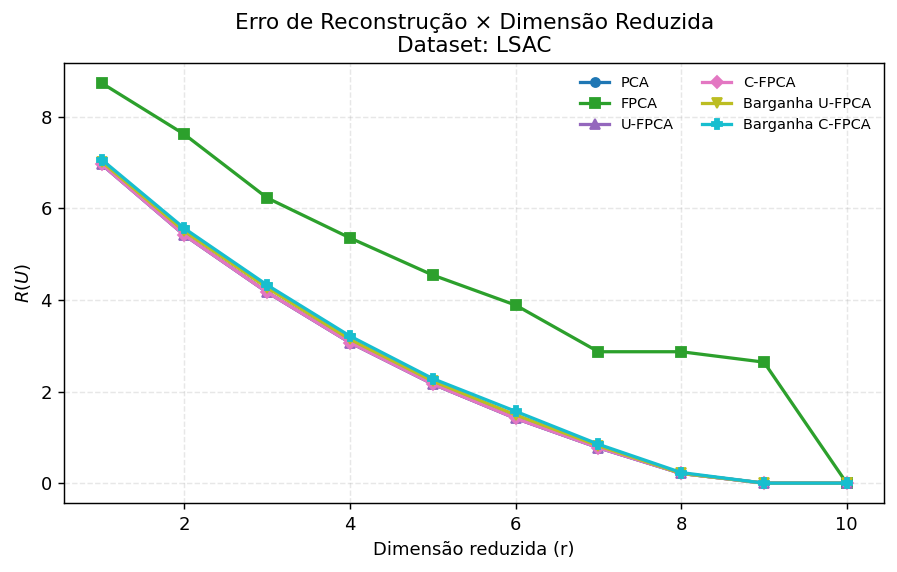

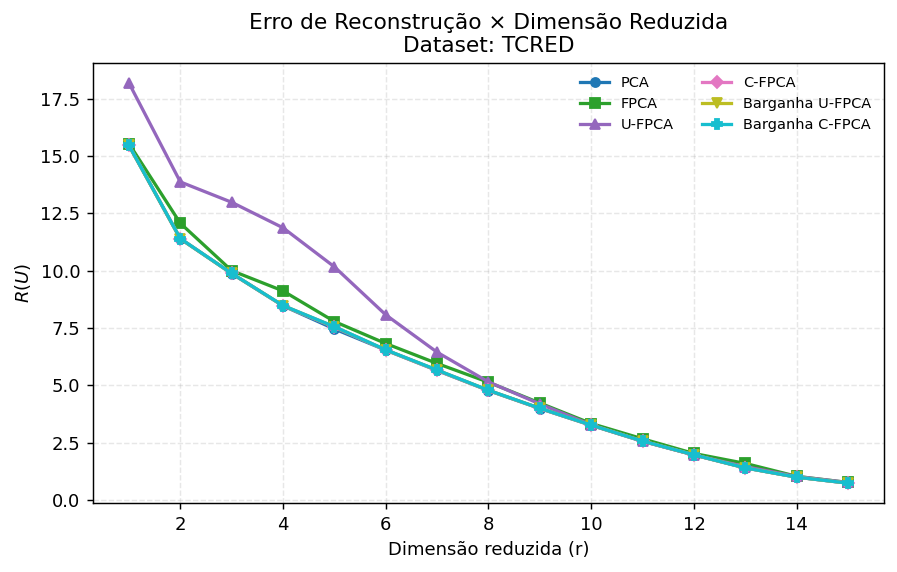

In [359]:
ALGOS_ORDEM = ["PCA", "FPCA", "U-FPCA", "C-FPCA", "Barganha U-FPCA", "Barganha C-FPCA"]
CORES = plt.cm.tab10(np.linspace(0, 1, len(ALGOS_ORDEM)))
MARCADORES = ["o", "s", "^", "D", "v", "P"]

def plot_metrica(df_res, coluna, titulo, ylabel, nome_dataset):
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
    for algo, cor, mk in zip(ALGOS_ORDEM, CORES, MARCADORES):
        sub = df_res[df_res["algoritmo"] == algo].sort_values("r")
        if sub.empty:
            continue
        ax.plot(sub["r"], sub[coluna], marker=mk, color=cor, label=algo,
                linewidth=1.8, markersize=5)
    ax.set_xlabel("Dimensão reduzida (r)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{titulo}\nDataset: {nome_dataset}")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    ax.grid(alpha=0.3, linestyle="--")
    fig.tight_layout()
    plt.show()


for nome_dataset, res in resultados_por_dataset.items():
    plot_metrica(res["df"], "R", "Erro de Reconstrução × Dimensão Reduzida",
                 r"$R(U)$", nome_dataset)


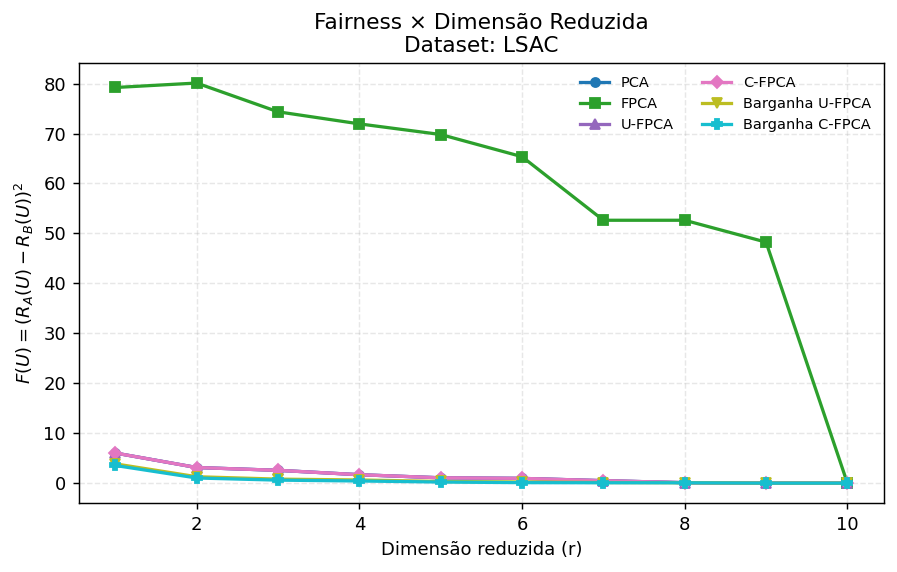

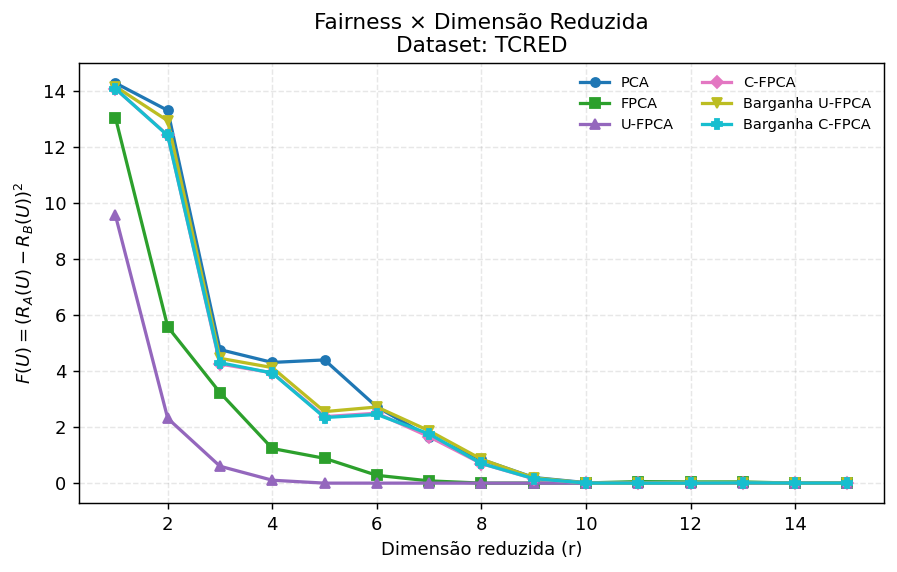

In [360]:
for nome_dataset, res in resultados_por_dataset.items():
    plot_metrica(res["df"], "F", "Fairness × Dimensão Reduzida",
                 r"$F(U) = \left(R_A(U) - R_B(U)\right)^2$", nome_dataset)


### 14.1 α por dimensão — U-FPCA vs. peso endógeno da Barganha

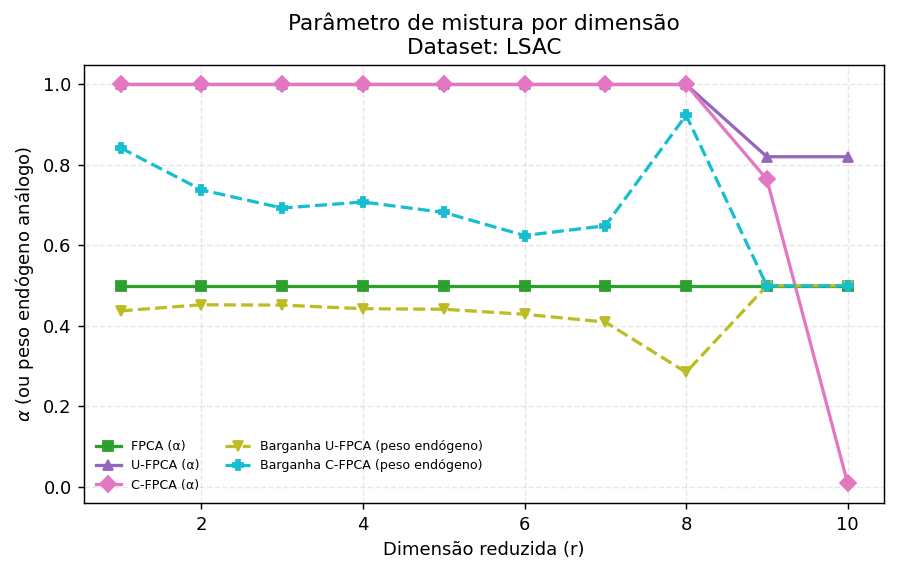

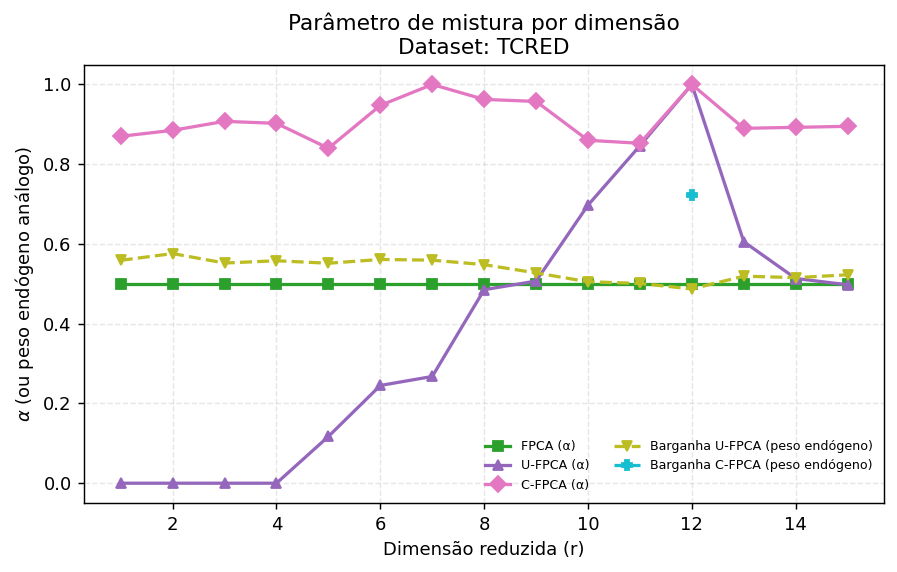

In [361]:
def plot_alpha(df_res, nome_dataset):
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
    for algo, cor, mk in zip(["FPCA", "U-FPCA", "C-FPCA"], CORES[1:4], MARCADORES[1:4]):
        sub = df_res[df_res["algoritmo"] == algo].sort_values("r")
        ax.plot(sub["r"], sub["alpha"], marker=mk, color=cor, label=f"{algo} (α)", linewidth=1.8)
    for algo, cor, mk in zip(["Barganha U-FPCA", "Barganha C-FPCA"], CORES[4:], MARCADORES[4:]):
        sub = df_res[df_res["algoritmo"] == algo].sort_values("r")
        ax.plot(sub["r"], sub["alpha"], marker=mk, color=cor, linestyle="--",
                 label=f"{algo} (peso endógeno)", linewidth=1.8)
    ax.set_xlabel("Dimensão reduzida (r)")
    ax.set_ylabel(r"$\alpha$ (ou peso endógeno análogo)")
    ax.set_title(f"Parâmetro de mistura por dimensão\nDataset: {nome_dataset}")
    ax.legend(frameon=False, fontsize=7, ncol=2)
    ax.grid(alpha=0.3, linestyle="--")
    fig.tight_layout()
    plt.show()


for nome_dataset, res in resultados_por_dataset.items():
    plot_alpha(res["df"], nome_dataset)


### 14.2 Evolução da função objetivo dos modelos de barganha

Para cada algoritmo de barganha, escolhemos o valor de `r` com o **histórico
mais longo** (mais passos de gradiente) entre os `r` testados — em dimensões
muito altas (próximas de `d`) o erro de reconstrução tende a zero e a
otimização converge em 1 passo, o que deixaria o gráfico vazio se o `r`
escolhido fosse sempre o máximo.


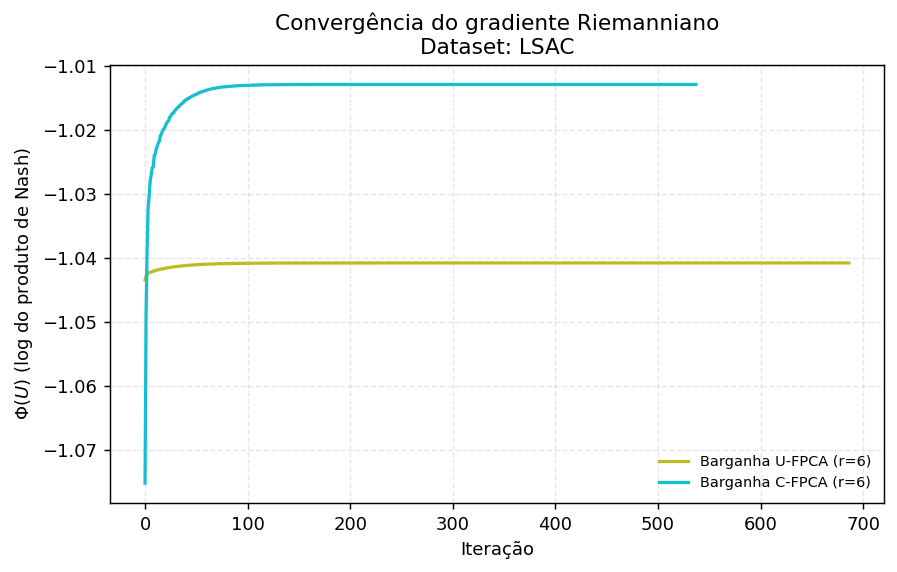

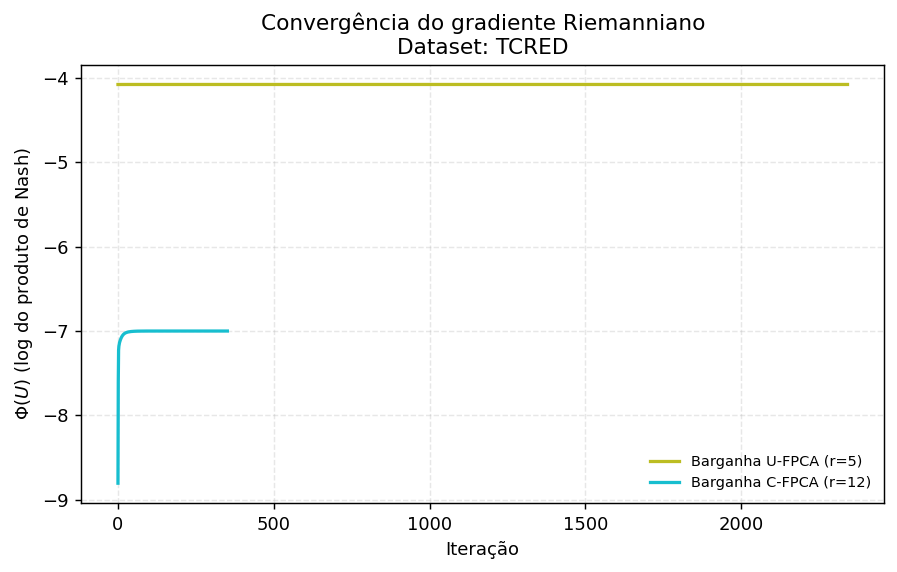

In [362]:
def escolher_r_mais_informativo(hist_dict, algo, r_max):
    """Retorna o r (excluindo r_max, tipicamente trivial) com histórico mais
    longo para o algoritmo dado; usa r_max apenas se não houver outra opção."""
    candidatos = [(r, hist_dict.get((algo, r), np.array([])))
                  for r in range(1, r_max)]  # exclui r_max de propósito
    candidatos = [(r, h) for r, h in candidatos if h.size > 1]
    if not candidatos:
        h = hist_dict.get((algo, r_max), np.array([]))
        return (r_max, h) if h.size > 1 else (None, np.array([]))
    return max(candidatos, key=lambda rc: rc[1].size)


def plot_convergencia(hist_dict, r_max, nome_dataset):
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
    algo_plotado = False
    for algo, cor in zip(["Barganha U-FPCA", "Barganha C-FPCA"], CORES[4:]):
        r_escolhido, hist = escolher_r_mais_informativo(hist_dict, algo, r_max)
        if hist.size > 1:
            ax.plot(hist, color=cor, label=f"{algo} (r={r_escolhido})", linewidth=1.8)
            algo_plotado = True
    ax.set_xlabel("Iteração")
    ax.set_ylabel(r"$\Phi(U)$ (log do produto de Nash)")
    ax.set_title(f"Convergência do gradiente Riemanniano\nDataset: {nome_dataset}")
    if algo_plotado:
        ax.legend(frameon=False, fontsize=8)
    else:
        ax.text(0.5, 0.5, "Nenhum histórico com mais de 1 iteração\n"
                           "(otimização convergiu imediatamente em todos os r)",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)
    ax.grid(alpha=0.3, linestyle="--")
    fig.tight_layout()
    plt.show()


for nome_dataset, res in resultados_por_dataset.items():
    plot_convergencia(res["hist"], res["dados"]["r_max"], nome_dataset)


### 14.3 Tempo de execução por algoritmo

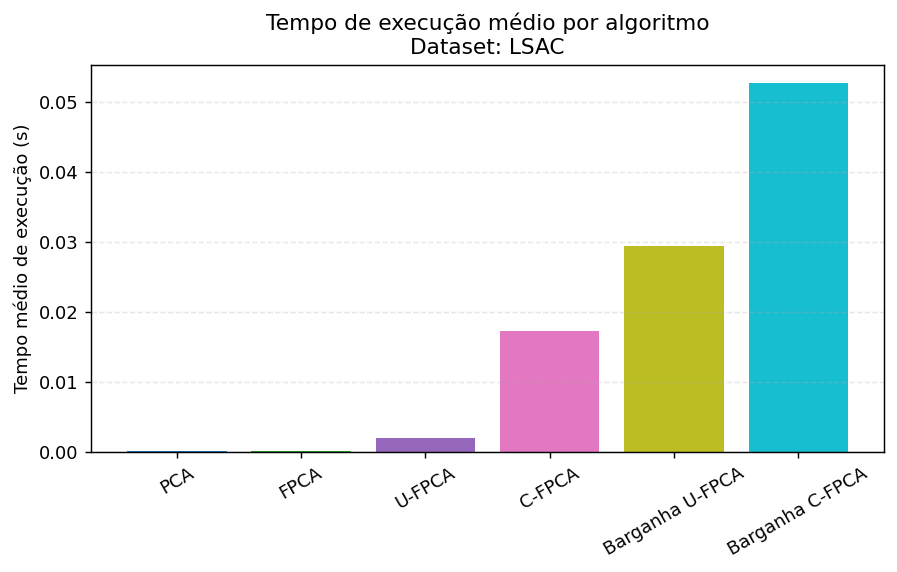

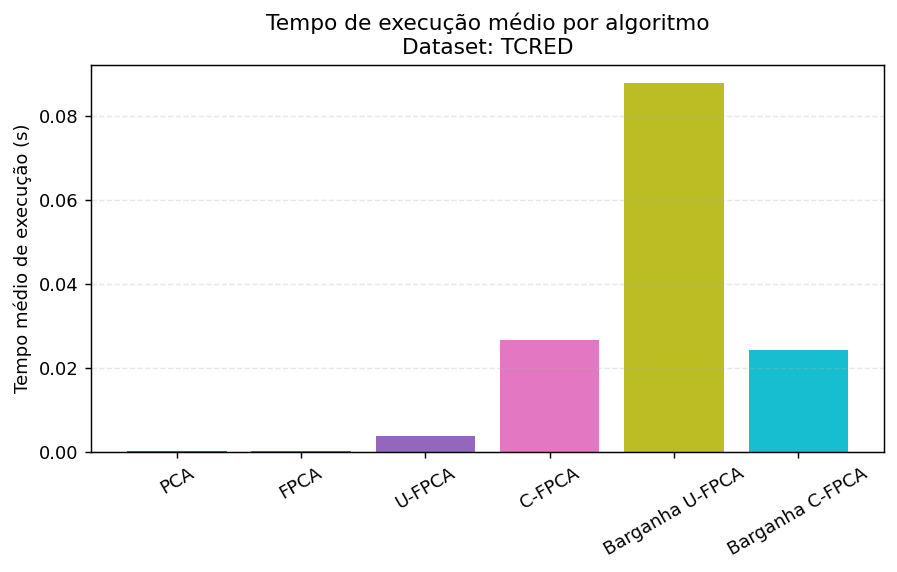

In [363]:
def plot_tempo(df_res, nome_dataset):
    tempo_medio = (df_res.groupby("algoritmo")["tempo"].mean().reindex(ALGOS_ORDEM))
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
    ax.bar(tempo_medio.index, tempo_medio.values, color=CORES)
    ax.set_ylabel("Tempo médio de execução (s)")
    ax.set_title(f"Tempo de execução médio por algoritmo\nDataset: {nome_dataset}")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.3, linestyle="--", axis="y")
    fig.tight_layout()
    plt.show()


for nome_dataset, res in resultados_por_dataset.items():
    plot_tempo(res["df"], nome_dataset)


## 15. Tabelas finais

Para cada dataset: tabela completa (todos os `r`) e tabela-resumo com os
valores finais (R_A, R_B, R, fairness F = D², α) na maior dimensão testada,
útil para compor a tabela comparativa do artigo. As tabelas ficam apenas
no notebook (nenhum arquivo CSV é gerado).


In [364]:
for nome_dataset, res in resultados_por_dataset.items():
    print(f"\n===== {nome_dataset}: tabela completa (todos os r) =====")
    tabela_completa = (res["df"]
                        .assign(algoritmo=lambda d: pd.Categorical(d["algoritmo"], ALGOS_ORDEM, ordered=True))
                        .sort_values(["r", "algoritmo"])
                        .reset_index(drop=True))
    display(tabela_completa.round(4))



===== LSAC: tabela completa (todos os r) =====


,algoritmo,r,R_A,R_B,R,F,teto,alpha,tempo,viavel,motivo_parada,grad_norm_final,monotona
0,PCA,1,6.7951,9.2500,6.9606,6.0265,9.2500,NaN,0.0001,True,NaN,NaN,NaN
1,FPCA,1,8.1349,17.0355,8.7350,79.2197,17.0355,0.5000,0.0000,True,NaN,NaN,NaN
2,U-FPCA,1,6.7951,9.2500,6.9606,6.0265,9.2500,1.0000,0.0020,True,NaN,NaN,NaN
3,C-FPCA,1,6.7951,9.2500,6.9606,6.0265,9.2500,1.0000,0.0174,True,NaN,NaN,NaN
4,Barganha U-FPCA,1,6.8874,8.8520,7.0198,3.8597,8.8520,0.4376,0.0047,True,sem_passo_ascendente,0.0,True
5,Barganha C-FPCA,1,6.9377,8.8175,7.0644,3.5337,8.8175,0.8424,0.0079,True,sem_passo_ascendente,0.0,True
6,PCA,2,5.2963,7.0640,5.4154,3.1250,7.0640,NaN,0.0003,True,NaN,NaN,NaN
7,FPCA,2,7.0113,15.9618,7.6147,80.1130,15.9618,0.5000,0.0002,True,NaN,NaN,NaN
8,U-FPCA,2,5.2963,7.0640,5.4154,3.1250,7.0640,1.0000,0.0028,True,NaN,NaN,NaN
9,C-FPCA,2,5.2963,7.0640,5.4154,3.1250,7.0640,1.0000,0.0184,True,NaN,NaN,NaN



===== TCRED: tabela completa (todos os r) =====


,algoritmo,r,R_A,R_B,R,F,teto,alpha,tempo,viavel,motivo_parada,grad_norm_final,monotona
0,PCA,1,17.8456,14.0672,15.4589,14.2769,17.8456,NaN,0.0001,True,NaN,NaN,NaN
1,FPCA,1,17.8208,14.2093,15.5396,13.0428,17.8208,0.5000,0.0001,True,NaN,NaN,NaN
2,U-FPCA,1,20.2226,17.1314,18.1797,9.5559,20.2226,0.0000,0.0032,True,NaN,NaN,NaN
3,C-FPCA,1,17.8298,14.0786,15.4610,14.0714,17.8298,0.8700,0.0247,False,NaN,NaN,NaN
4,Barganha U-FPCA,1,17.8343,14.0723,15.4609,14.1520,17.8343,0.5590,0.0048,True,sem_passo_ascendente,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,FPCA,15,0.7549,0.7546,0.7580,0.0000,0.7549,0.5000,0.0001,True,NaN,NaN,NaN
86,U-FPCA,15,0.7550,0.7550,0.7584,0.0000,0.7550,0.4976,0.0032,True,NaN,NaN,NaN
87,C-FPCA,15,0.7665,0.7023,0.7307,0.0041,0.7665,0.8950,0.0257,False,NaN,NaN,NaN
88,Barganha U-FPCA,15,0.7673,0.7007,0.7309,0.0044,0.7673,0.5227,0.5108,True,sem_passo_ascendente,0.0,True


## 16. Q1 — O solver de barganha sobe Φ monotonicamente e converge de forma robusta?

Duas checagens, ambas sobre os dois modelos de barganha (U-FPCA e C-FPCA):

**16.1 Monotonicidade e motivo de parada**, agregados sobre todas as execuções
(todo `r`, ambos os datasets) — não apenas no exemplo da Seção 14.2. A coluna
`monotona` é calculada verificando `Φ` a cada iteração (não apenas assumida
pela construção do Armijo).

**16.2 Robustez à inicialização**: para um `r` representativo de cada dataset,
reotimizamos várias vezes a partir de pontos iniciais diferentes e comparamos
(a) o valor final de `Φ` e (b) o ângulo principal entre os subespaços
resultantes. Se o solver é robusto, inicializações diferentes devem convergir
para (aproximadamente) o mesmo `Φ` e o mesmo subespaço (ângulos ≈ 0°).


In [366]:
### 16.1 — Monotonicidade e motivo de parada (agregado)

for nome_dataset, res in resultados_por_dataset.items():
    df_barg = res["df"][res["df"]["algoritmo"].isin(["Barganha U-FPCA", "Barganha C-FPCA"])].copy()
    # 'monotona' é object (mistura True/False/NaN quando a inicialização falha —
    # cf. Seção 12); converte para float explicitamente antes de agregar, pois
    # groupby().agg(mean=...) não faz essa coerção automaticamente como
    # Series.mean() faz.
    df_barg["monotona_num"] = df_barg["monotona"].astype(float)

    print(f"\n===== {nome_dataset} =====")
    resumo_convergencia = (df_barg.groupby("algoritmo")
                            .agg(execucoes=("r", "count"),
                                 execucoes_com_iteracao=("monotona_num", "count"),  # exclui NaN (init inviável)
                                 pct_monotona=("monotona_num", "mean"),
                                 grad_norm_medio=("grad_norm_final", "mean"),
                                 grad_norm_max=("grad_norm_final", "max")))
    resumo_convergencia["pct_monotona"] = (resumo_convergencia["pct_monotona"] * 100).round(1)
    display(resumo_convergencia.round(6))

    print("Distribuição do motivo de parada:")
    display(df_barg.groupby(["algoritmo", "motivo_parada"]).size().unstack(fill_value=0))



===== LSAC =====


,execucoes,execucoes_com_iteracao,pct_monotona,grad_norm_medio,grad_norm_max
algoritmo,,,,,
Barganha C-FPCA,10,8,100.0,0.000002,0.000013
Barganha U-FPCA,10,8,100.0,0.000000,0.000000


Distribuição do motivo de parada:


motivo_parada,ponto_inicial_inviavel,sem_passo_ascendente
algoritmo,,
Barganha C-FPCA,2,8
Barganha U-FPCA,2,8



===== TCRED =====


,execucoes,execucoes_com_iteracao,pct_monotona,grad_norm_medio,grad_norm_max
algoritmo,,,,,
Barganha C-FPCA,15,1,100.0,0.000014,0.000014
Barganha U-FPCA,15,15,100.0,0.000000,0.000001


Distribuição do motivo de parada:


motivo_parada,sem_passo_ascendente,sem_ponto_inicial_viavel
algoritmo,,
Barganha C-FPCA,1,14
Barganha U-FPCA,15,0


In [367]:
### 16.2 — Robustez à inicialização (múltiplos restarts)

def ponto_aleatorio_stiefel(d, r, rng):
    A = rng.normal(size=(d, r))
    Q, _ = np.linalg.qr(A)
    return Q


def robustez_ufpca(CA, CB, r, n_restarts=6, seed=123):
    rng = np.random.default_rng(seed)
    d = CA.shape[0]
    phis, Us = [], []
    for _ in range(n_restarts):
        U0 = ponto_aleatorio_stiefel(d, r, rng)
        U, hist, alpha, info = barganha_ufpca(CA, CB, r, U0=U0)
        if info["motivo_parada"] != "ponto_inicial_inviavel":
            phis.append(hist[-1])
            Us.append(U)
    return phis, Us


def robustez_cfpca(CA, CB, r, tau, n_restarts=6, n_grid_beta=101, seed=123):
    """Usa vários pontos da família beta*C_A + (1-beta)*C_B que sejam
    estritamente viáveis como diferentes inicializações."""
    tau_eff = tau * (1 + 1e-6) if tau > 0 else tau + 1e-9
    betas_viaveis = []
    for beta in np.linspace(0.0, 1.0, n_grid_beta):
        U = top_k(beta * CA + (1 - beta) * CB, r)
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        if RA < tau_eff and RB < tau_eff:
            betas_viaveis.append(beta)
    if not betas_viaveis:
        return [], []
    idxs = np.linspace(0, len(betas_viaveis) - 1, min(n_restarts, len(betas_viaveis))).astype(int)
    phis, Us = [], []
    for i in idxs:
        beta = betas_viaveis[i]
        U0 = top_k(beta * CA + (1 - beta) * CB, r)
        U, hist, alpha, viavel, info = barganha_cfpca(CA, CB, r, tau=tau, U0=U0)
        if viavel and hist.size > 0:
            phis.append(hist[-1])
            Us.append(U)
    return phis, Us


for nome_dataset, res in resultados_por_dataset.items():
    dados = res["dados"]
    CA, CB = dados["CA"], dados["CB"]
    r_teste = max(1, dados["r_max"] // 2)   # r representativo (evita o caso trivial r=d)
    tau_teste = recon_error(CB, pca_classico(dados["CX"], r_teste))

    print(f"\n===== {nome_dataset}  (r = {r_teste} usado no teste de robustez) =====")

    phis_u, Us_u = robustez_ufpca(CA, CB, r_teste)
    if len(phis_u) >= 2:
        angulos_max = [angulos_principais(Us_u[0], U).max() for U in Us_u[1:]]
        print(f"Barganha U-FPCA — Φ final em {len(phis_u)} restarts: "
              f"média={np.mean(phis_u):.6f}, desvio-padrão={np.std(phis_u):.2e}")
        print(f"  maior ângulo principal entre subespaços (vs. o 1º restart): "
              f"{max(angulos_max):.4f}°  (0° = mesmo subespaço)")
    else:
        print("Barganha U-FPCA — poucos restarts viáveis para avaliar robustez.")

    phis_c, Us_c = robustez_cfpca(CA, CB, r_teste, tau_teste)
    if len(phis_c) >= 2:
        angulos_max = [angulos_principais(Us_c[0], U).max() for U in Us_c[1:]]
        print(f"Barganha C-FPCA — Φ final em {len(phis_c)} restarts: "
              f"média={np.mean(phis_c):.6f}, desvio-padrão={np.std(phis_c):.2e}")
        print(f"  maior ângulo principal entre subespaços (vs. o 1º restart): "
              f"{max(angulos_max):.4f}°  (0° = mesmo subespaço)")
    else:
        print("Barganha C-FPCA — poucos pontos iniciais viáveis para avaliar robustez "
              "(região viável muito estreita nesse r/τ).")



===== LSAC  (r = 5 usado no teste de robustez) =====
Barganha U-FPCA — Φ final em 6 restarts: média=-1.801387, desvio-padrão=1.98e-15
  maior ângulo principal entre subespaços (vs. o 1º restart): 0.0000°  (0° = mesmo subespaço)
Barganha C-FPCA — Φ final em 6 restarts: média=-1.025037, desvio-padrão=3.21e-14
  maior ângulo principal entre subespaços (vs. o 1º restart): 0.0000°  (0° = mesmo subespaço)

===== TCRED  (r = 7 usado no teste de robustez) =====
Barganha U-FPCA — Φ final em 6 restarts: média=-3.484975, desvio-padrão=7.64e-15
  maior ângulo principal entre subespaços (vs. o 1º restart): 0.0002°  (0° = mesmo subespaço)
Barganha C-FPCA — poucos pontos iniciais viáveis para avaliar robustez (região viável muito estreita nesse r/τ).


## 17. Q2 — A solução de barganha difere do Fair PCA de disparidade ao quadrado? Com que consequência para o teto de cada grupo?

Duas evidências, calculadas para **todo `r` e ambos os datasets** (não apenas
um ponto):

**17.1 Teto do grupo** (`teto = max(R_A, R_B)`, já calculado na Seção 13):
comparamos par a par **U-FPCA vs. Barganha U-FPCA** e **C-FPCA vs. Barganha
C-FPCA** — quem impõe o pior erro ao grupo mais penalizado, em cada `r`?

**17.2 Ângulo principal entre subespaços**: mesmo quando as métricas (R_A, R_B,
F, teto) são parecidas, os subespaços `U` podem ser diferentes. Calculamos o
maior ângulo principal entre `U` da barganha e `U` do FPCA de disparidade²
correspondente, em cada `r`. Ângulo 0° = mesmo subespaço; valores maiores
indicam soluções genuinamente diferentes, não apenas coincidências numéricas
nas métricas agregadas.


In [368]:
### 17.1 — Comparação pareada: teto do grupo (max(R_A, R_B))

def comparar_pares(df_res, par):
    """par = (nome_original, nome_barganha). Retorna tabela por r com a
    diferença de teto e de F entre os dois algoritmos do par."""
    nome_orig, nome_barg = par
    a = df_res[df_res["algoritmo"] == nome_orig].set_index("r")
    b = df_res[df_res["algoritmo"] == nome_barg].set_index("r")
    comp = pd.DataFrame({
        f"teto_{nome_orig}": a["teto"],
        f"teto_{nome_barg}": b["teto"],
        "delta_teto (barganha - original)": b["teto"] - a["teto"],
        f"F_{nome_orig}": a["F"],
        f"F_{nome_barg}": b["F"],
        "delta_F (barganha - original)": b["F"] - a["F"],
    })
    return comp.round(5)


PARES = [("U-FPCA", "Barganha U-FPCA"), ("C-FPCA", "Barganha C-FPCA")]

for nome_dataset, res in resultados_por_dataset.items():
    for par in PARES:
        print(f"\n===== {nome_dataset}: {par[0]} vs. {par[1]} =====")
        display(comparar_pares(res["df"], par))



===== LSAC: U-FPCA vs. Barganha U-FPCA =====


,teto_U-FPCA,teto_Barganha U-FPCA,delta_teto (barganha - original),F_U-FPCA,F_Barganha U-FPCA,delta_F (barganha - original)
r,,,,,,
1,9.24998,8.85198,-0.39800,6.02650,3.85972,-2.16678
2,7.06401,6.55693,-0.50709,3.12498,1.28391,-1.84107
3,5.66088,5.09987,-0.56101,2.56409,0.80302,-1.76107
4,4.28063,3.88262,-0.39801,1.68726,0.63410,-1.05316
5,3.12733,2.76781,-0.35951,1.06657,0.33532,-0.73125
6,2.32471,1.94090,-0.38381,0.95176,0.23252,-0.71924
7,1.42883,1.14069,-0.28813,0.49309,0.12181,-0.37128
8,0.49711,0.48489,-0.01221,0.09371,0.08504,-0.00867
9,0.00000,0.00000,-0.00000,0.00000,0.00000,-0.00000



===== LSAC: C-FPCA vs. Barganha C-FPCA =====


,teto_C-FPCA,teto_Barganha C-FPCA,delta_teto (barganha - original),F_C-FPCA,F_Barganha C-FPCA,delta_F (barganha - original)
r,,,,,,
1,9.24998,8.81752,-0.43246,6.02650,3.53372,-2.49278
2,7.06401,6.50660,-0.55741,3.12498,1.02900,-2.09598
3,5.66088,5.04565,-0.61523,2.56409,0.59840,-1.96569
4,4.28063,3.82125,-0.45938,1.68726,0.42850,-1.25876
5,3.12733,2.71841,-0.40891,1.06657,0.21948,-0.84709
6,2.32471,1.85764,-0.46707,0.95176,0.09643,-0.85533
7,1.42883,1.10516,-0.32366,0.49309,0.07558,-0.41750
8,0.49711,0.47369,-0.02342,0.09371,0.06757,-0.02614
9,0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000



===== TCRED: U-FPCA vs. Barganha U-FPCA =====


,teto_U-FPCA,teto_Barganha U-FPCA,delta_teto (barganha - original),F_U-FPCA,F_Barganha U-FPCA,delta_F (barganha - original)
r,,,,,,
1,20.22261,17.83426,-2.38836,9.55585,14.15201,4.59615
2,14.83474,13.64632,-1.18842,2.31175,12.93191,10.62015
3,13.50181,11.17328,-2.32852,0.60266,4.45499,3.85233
4,12.04617,9.78161,-2.26455,0.10360,4.12309,4.01948
5,10.11014,8.53092,-1.57923,0.00000,2.55224,2.55224
6,8.01324,7.55895,-0.45430,0.00000,2.71671,2.71671
7,6.43280,6.43565,0.00285,0.00000,1.86805,1.86805
8,5.09024,5.26958,0.17934,0.00000,0.85448,0.85448
9,4.12267,4.17631,0.05363,0.00000,0.18809,0.18809



===== TCRED: C-FPCA vs. Barganha C-FPCA =====


,teto_C-FPCA,teto_Barganha C-FPCA,delta_teto (barganha - original),F_C-FPCA,F_Barganha C-FPCA,delta_F (barganha - original)
r,,,,,,
1,17.82977,17.82895,-0.00081,14.07139,14.07680,0.00540
2,13.60973,13.60657,-0.00316,12.41695,12.40535,-0.01160
3,11.15187,11.15341,0.00154,4.24973,4.29720,0.04747
4,9.76471,9.75605,-0.00865,3.93714,3.92948,-0.00766
5,8.53075,8.49514,-0.03560,2.37310,2.34030,-0.03280
6,7.53493,7.51499,-0.01993,2.49510,2.45124,-0.04386
7,6.42592,6.41352,-0.01240,1.65682,1.75575,0.09893
8,5.23320,5.22385,-0.00935,0.69775,0.70077,0.00301
9,4.16666,4.16020,-0.00645,0.15490,0.16191,0.00701


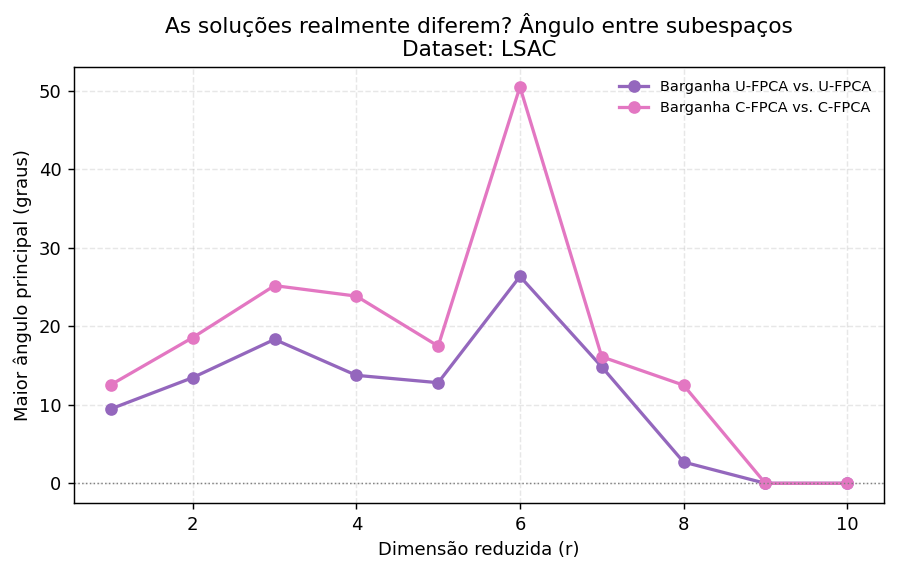

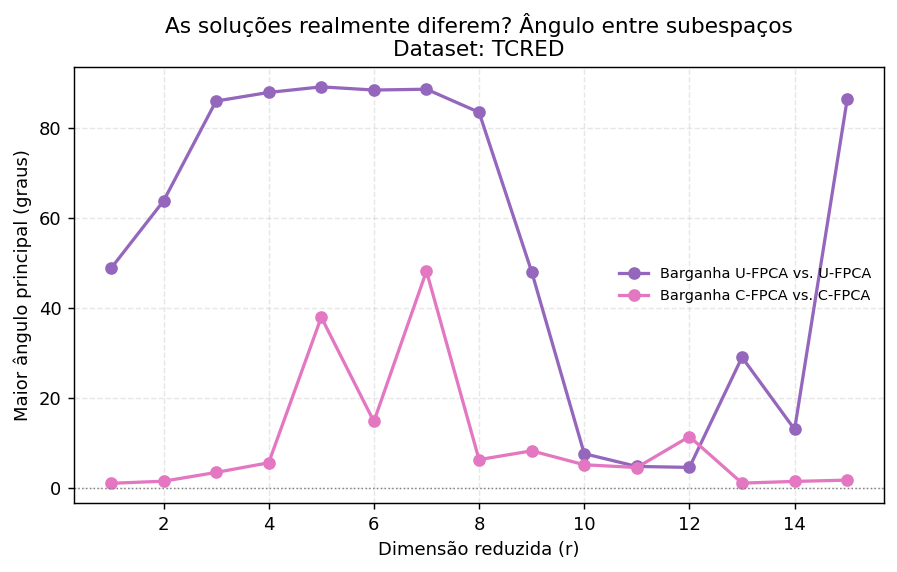

In [369]:
### 17.2 — Ângulo principal entre os subespaços (barganha vs. FPCA de F=D²)

def angulos_por_par(matrizes_U, par, r_max):
    nome_orig, nome_barg = par
    linhas = []
    for r in range(1, r_max + 1):
        U_o = matrizes_U.get((nome_orig, r))
        U_b = matrizes_U.get((nome_barg, r))
        if U_o is None or U_b is None:
            continue
        ang = angulos_principais(U_o, U_b)
        linhas.append(dict(r=r, angulo_max_graus=ang.max(), angulo_medio_graus=ang.mean()))
    return pd.DataFrame(linhas)


for nome_dataset, res in resultados_por_dataset.items():
    dados = res["dados"]
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
    for par, cor in zip(PARES, CORES[[2, 3]]):
        df_ang = angulos_por_par(res["matrizes_U"], par, dados["r_max"])
        if not df_ang.empty:
            ax.plot(df_ang["r"], df_ang["angulo_max_graus"], marker="o",
                    color=cor, label=f"{par[1]} vs. {par[0]}", linewidth=1.8)
    ax.set_xlabel("Dimensão reduzida (r)")
    ax.set_ylabel("Maior ângulo principal (graus)")
    ax.set_title(f"As soluções realmente diferem? Ângulo entre subespaços\nDataset: {nome_dataset}")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.3, linestyle="--")
    fig.tight_layout()
    plt.show()


## 18. Fronteira de Pareto: C-FPCA vs. NBS e U-FPCA vs. NBS (evidência empírica para Q1 e Q2)

Reproduz, com os dados reais dos dois datasets, o experimento da Seção 7.2 do
relatório teórico (Figuras 1 e 3 do relatório) — mas para **os dois pares**
de algoritmos (C-FPCA/Barganha C-FPCA **e** U-FPCA/Barganha U-FPCA), nos
**dois datasets**.

- **Painel C-FPCA** (espaço de folgas `s_A = τ - R_A`, `s_B = τ - R_B`): a
  curva cinza é a fronteira gerada pela família de covariâncias
  `β·C_A + (1-β)·C_B` (a mesma família que o C-FPCA original percorre); a
  região rosa é inviável (algum grupo ultrapassa `τ`); a curva pontilhada azul
  é a curva de nível do produto de Nash que passa pela solução da barganha; a
  cinza tracejada é a reta de equalização `s_A = s_B`. **Evidência para Q1**:
  a solução da barganha (círculo vermelho) deve sempre cair na região viável
  (`s_A, s_B > 0`); **evidência para Q2**: se o quadrado verde (C-FPCA
  original) cai fora da região viável ou longe do círculo vermelho, as duas
  soluções realmente divergem.

- **Painel U-FPCA** (espaço de utilidades `Q_A = 1/R_A`, `Q_B = 1/R_B`):
  mesma lógica, mas sem restrição de viabilidade (não há região inviável a
  destacar) — a curva cinza vem da família `α·C_X + (1-α)(C_A - C_B)` que o
  U-FPCA original percorre.

Como no restante do notebook, escolhemos um `r` representativo por dataset
(evitando o caso trivial `r = d`, em que a reconstrução é exata e o gráfico
degenera — cf. discussão da Figura 7(b) do relatório teórico).


In [370]:
def frontera_familia_cfpca(CA, CB, r, tau, n_grid=201):
    """Traça (s_A(beta), s_B(beta)) ao longo de beta*C_A + (1-beta)*C_B,
    a mesma família de covariâncias que o C-FPCA original percorre."""
    betas = np.linspace(0.0, 1.0, n_grid)
    sA, sB = [], []
    for beta in betas:
        U = top_k(beta * CA + (1 - beta) * CB, r)
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        sA.append(tau - RA)
        sB.append(tau - RB)
    return np.array(sA), np.array(sB)


def frontera_familia_ufpca(CX, CA, CB, r, n_grid=201):
    """Traça (Q_A(alpha), Q_B(alpha)) ao longo de Ĉ(alpha), a mesma família
    que o U-FPCA original percorre."""
    alphas = np.linspace(0.0, 1.0, n_grid)
    QA, QB = [], []
    for alpha in alphas:
        U = top_k(chat_alpha(CX, CA, CB, alpha), r)
        RA, RB = recon_error(CA, U), recon_error(CB, U)
        QA.append(1.0 / max(RA, 1e-12))
        QB.append(1.0 / max(RB, 1e-12))
    return np.array(QA), np.array(QB)


def curva_nash(x0, y0, wA, wB, x_range, n_pontos=200):
    """Curva de nível x^wA * y^wB = c passando por (x0, y0), amostrada em
    x_range (usada como a 'curva de Nash' pontilhada dos gráficos de Pareto)."""
    c = (x0 ** wA) * (y0 ** wB) if x0 > 0 and y0 > 0 else np.nan
    xs = np.linspace(max(x_range[0], 1e-9), x_range[1], n_pontos)
    with np.errstate(all="ignore"):
        ys = (c / xs ** wA) ** (1.0 / wB)
    return xs, ys


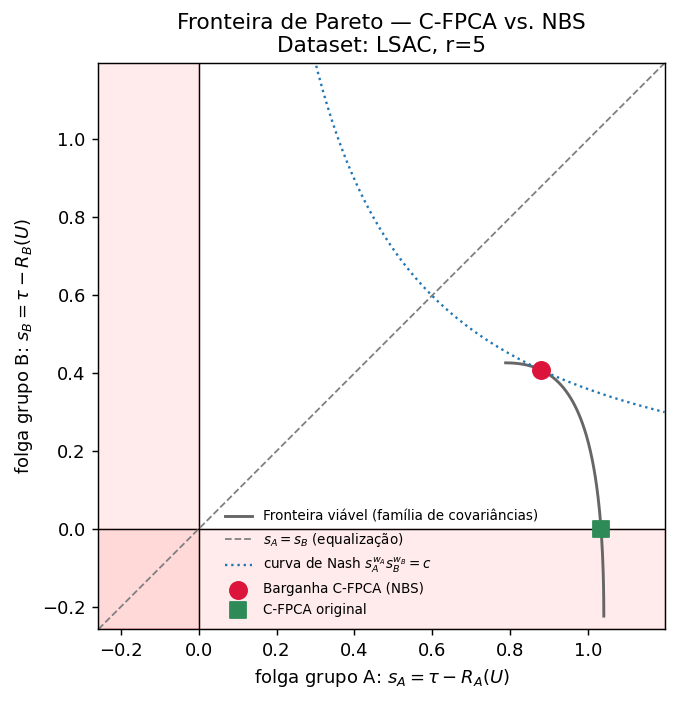

  [LSAC, r=5] C-FPCA viável: True  |  Barganha C-FPCA viável: True


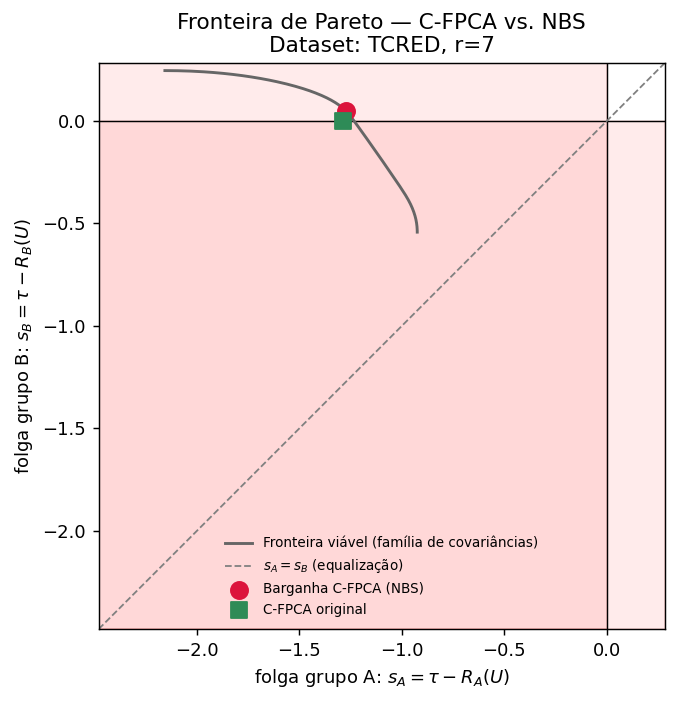

  [TCRED, r=7] C-FPCA viável: False  |  Barganha C-FPCA viável: False


In [371]:
def plot_pareto_cfpca(dados, r, nome_dataset, wA=None, wB=None):
    CX, CA, CB = dados["CX"], dados["CA"], dados["CB"]
    if wA is None: wA = BARGAIN_WEIGHTS["A"]
    if wB is None: wB = BARGAIN_WEIGHTS["B"]

    tau = recon_error(CB, pca_classico(CX, r))
    sA_front, sB_front = frontera_familia_cfpca(CA, CB, r, tau)

    U_c, alpha_c, viavel_c = cfpca(CX, CA, CB, r, tau=tau)
    sA_c = tau - recon_error(CA, U_c)
    sB_c = tau - recon_error(CB, U_c)

    U_bc, hist_bc, alpha_bc, viavel_bc, info_bc = barganha_cfpca(CA, CB, r, tau=tau)
    sA_bc = tau - recon_error(CA, U_bc)
    sB_bc = tau - recon_error(CB, U_bc)

    fig, ax = plt.subplots(figsize=(6, 5.5), dpi=130)

    lim_inf = min(sA_front.min(), sB_front.min(), sA_c, sB_c, sA_bc, sB_bc, 0) * 1.15
    lim_sup = max(sA_front.max(), sB_front.max(), sA_c, sB_c, sA_bc, sB_bc) * 1.15

    # região inviável (algum slack <= 0)
    ax.axvspan(lim_inf, 0, color="red", alpha=0.08, zorder=0)
    ax.axhspan(lim_inf, 0, color="red", alpha=0.08, zorder=0)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)

    ax.plot(sA_front, sB_front, color="0.4", linewidth=1.6,
            label="Fronteira viável (família de covariâncias)")

    diag = np.linspace(lim_inf, lim_sup, 10)
    ax.plot(diag, diag, "--", color="gray", linewidth=1.0, label=r"$s_A = s_B$ (equalização)")

    if sA_bc > 0 and sB_bc > 0:
        xs, ys = curva_nash(sA_bc, sB_bc, wA, wB, (lim_inf, lim_sup))
        ax.plot(xs, ys, ":", color="tab:blue", linewidth=1.3,
                label=r"curva de Nash $s_A^{w_A} s_B^{w_B}=c$")

    ax.scatter([sA_bc], [sB_bc], color="crimson", s=90, zorder=5,
               label="Barganha C-FPCA (NBS)")
    ax.scatter([sA_c], [sB_c], color="seagreen", s=80, marker="s", zorder=5,
               label="C-FPCA original")

    ax.set_xlim(lim_inf, lim_sup)
    ax.set_ylim(lim_inf, lim_sup)
    ax.set_xlabel(r"folga grupo A: $s_A = \tau - R_A(U)$")
    ax.set_ylabel(r"folga grupo B: $s_B = \tau - R_B(U)$")
    ax.set_title(f"Fronteira de Pareto — C-FPCA vs. NBS\nDataset: {nome_dataset}, r={r}")
    ax.legend(frameon=False, fontsize=7.5, loc="best")
    ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    plt.show()

    print(f"  [{nome_dataset}, r={r}] C-FPCA viável: {viavel_c}  |  "
          f"Barganha C-FPCA viável: {sA_bc > 0 and sB_bc > 0}")


for nome_dataset, res in resultados_por_dataset.items():
    dados = res["dados"]
    r_pareto = max(1, dados["r_max"] // 2)   # evita o caso trivial r=d
    plot_pareto_cfpca(dados, r_pareto, nome_dataset)


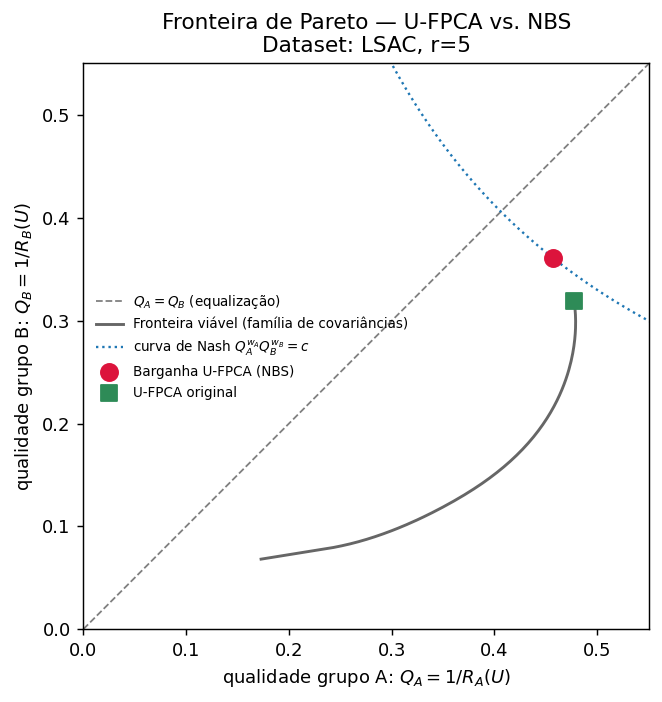

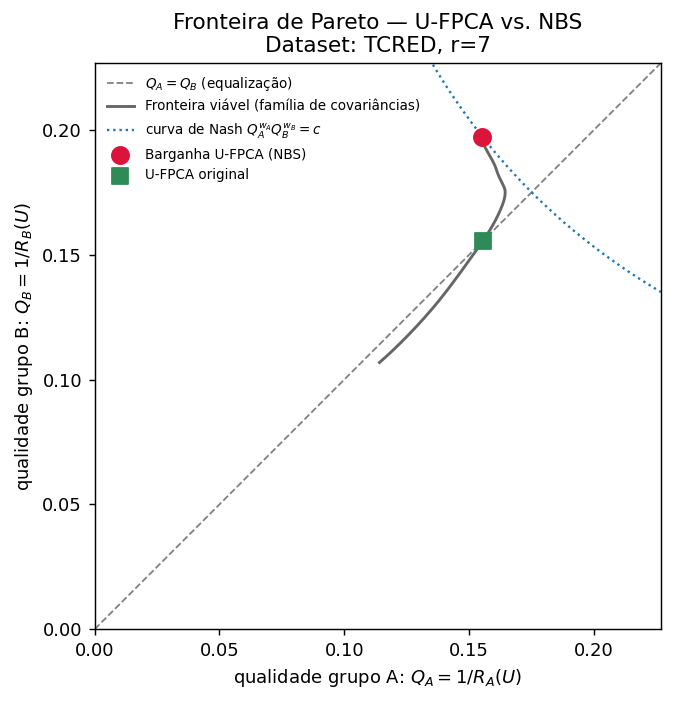

In [372]:
def plot_pareto_ufpca(dados, r, nome_dataset, wA=None, wB=None):
    CX, CA, CB = dados["CX"], dados["CA"], dados["CB"]
    if wA is None: wA = BARGAIN_WEIGHTS["A"]
    if wB is None: wB = BARGAIN_WEIGHTS["B"]

    QA_front, QB_front = frontera_familia_ufpca(CX, CA, CB, r)

    U_u, alpha_u = ufpca(CX, CA, CB, r)
    QA_u = 1.0 / max(recon_error(CA, U_u), 1e-12)
    QB_u = 1.0 / max(recon_error(CB, U_u), 1e-12)

    U_bu, hist_bu, alpha_bu, info_bu = barganha_ufpca(CA, CB, r)
    QA_bu = 1.0 / max(recon_error(CA, U_bu), 1e-12)
    QB_bu = 1.0 / max(recon_error(CB, U_bu), 1e-12)

    fig, ax = plt.subplots(figsize=(6, 5.5), dpi=130)

    lim_inf = 0.0
    lim_sup = max(QA_front.max(), QB_front.max(), QA_u, QB_u, QA_bu, QB_bu) * 1.15

    diag = np.linspace(lim_inf, lim_sup, 10)
    ax.plot(diag, diag, "--", color="gray", linewidth=1.0, label=r"$Q_A = Q_B$ (equalização)")

    ax.plot(QA_front, QB_front, color="0.4", linewidth=1.6,
            label="Fronteira viável (família de covariâncias)")

    xs, ys = curva_nash(QA_bu, QB_bu, wA, wB, (lim_inf, lim_sup))
    ax.plot(xs, ys, ":", color="tab:blue", linewidth=1.3,
            label=r"curva de Nash $Q_A^{w_A} Q_B^{w_B}=c$")

    ax.scatter([QA_bu], [QB_bu], color="crimson", s=90, zorder=5,
               label="Barganha U-FPCA (NBS)")
    ax.scatter([QA_u], [QB_u], color="seagreen", s=80, marker="s", zorder=5,
               label="U-FPCA original")

    ax.set_xlim(lim_inf, lim_sup)
    ax.set_ylim(lim_inf, lim_sup)
    ax.set_xlabel(r"qualidade grupo A: $Q_A = 1/R_A(U)$")
    ax.set_ylabel(r"qualidade grupo B: $Q_B = 1/R_B(U)$")
    ax.set_title(f"Fronteira de Pareto — U-FPCA vs. NBS\nDataset: {nome_dataset}, r={r}")
    ax.legend(frameon=False, fontsize=7.5, loc="best")
    ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    plt.show()


for nome_dataset, res in resultados_por_dataset.items():
    dados = res["dados"]
    r_pareto = max(1, dados["r_max"] // 2)   # evita o caso trivial r=d
    plot_pareto_ufpca(dados, r_pareto, nome_dataset)


---
### Observações finais

- A métrica de fairness usada em todo o notebook é **F(U) = D(U)² = (R_A(U) - R_B(U))²** — o quadrado da disparidade D(U) = R_A(U) - R_B(U) entre os erros de reconstrução dos dois grupos. É `F` que U-FPCA e C-FPCA minimizam, e é `F` que aparece nos gráficos e tabelas.
- **Fair PCA clássico** foi implementado com α fixo (0.5) como baseline "ingênuo" de mistura entre PCA e o termo de diferença de covariâncias — ajuste esse valor na Seção 8 caso seu enunciado defina outro critério para o α fixo.
- **C-FPCA** e **Barganha C-FPCA** usam τ = R_B(U_PCA) por dimensão `r`, conforme especificado. Se, para algum `r`, nenhuma solução estritamente viável for encontrada, a coluna `viavel` sinaliza `False`.
- Os pesos `w_A, w_B` da barganha de Nash (`BARGAIN_WEIGHTS`, Seção 3) representam o poder de barganha de cada grupo; `(0.5, 0.5)` corresponde à barganha simétrica clássica.
- Os dois datasets (`LSAC` e `TCRED`) são processados de forma independente — os resultados, gráficos e tabelas de um não interferem no outro. Para rodar só um deles, edite a lista `DATASETS` na Seção 3.
- As Seções 16-18 respondem duas perguntas de pesquisa específicas: **Q1** (o solver de barganha sobe Φ monotonicamente e converge de forma robusta?) e **Q2** (a solução de barganha difere do Fair PCA de disparidade ao quadrado, e com que consequência para o teto de cada grupo?). A Seção 18 reproduz o experimento de fronteira de Pareto do relatório teórico, com dados reais dos dois datasets, para os dois pares de algoritmos.
